# Ekonomi Geneli Etki Performans Endeksi (Economy-wide Impact Performance Index - EIPI) — Uçtan Uca CGE Analizi

## 1. Giriş ve Analitik Çerçeve

Bu defter, `EIPI_Analysis_Prompt.md` talimatlarını uygulayarak **SAM-kalibreli hesaplanabilir genel
denge (CGE) modeli** kurar, her sektör için ayrı ayrı **%10 toplam faktör verimliliği (TFP) şoku**
uygular ve şokların ekonomi geneli etkilerinden **EIPI (Ekonomi Geneli Etki Performans Endeksi)**'ni
inşa eder.

**Ne yapılıyor:** 62 sektörlük bir Sosyal Hesaplar Matrisi (SAM) temel alınarak Pyomo/IPOPT ile
doğrusal olmayan bir CGE modeli kalibre edilir ve çözülür; ardından her sektöre tek tek verimlilik
şoku uygulanarak şokun GSYH, refah, dış ticaret, emek geliri ve yayılma etkisi üzerindeki etkisi
ölçülür.

**Neden CGE ile ölçülüyor:** Ağ tabanlı SNII (Structural Network Importance Index), bir sektörün
üretim ağındaki **yapısal** konumunu ölçer, ama fiyat ayarlanması, faktör yeniden tahsisi, dış ticaret
tepkisi gibi **genel denge geri beslemelerini** yakalayamaz. CGE modeli tam olarak bunu yapar: bir
sektördeki verimlilik artışının ekonominin geri kalanına nasıl yayıldığını (fiyatlar, ücretler, ticaret
dengesi, refah üzerinden) sayısal olarak çözer.

**SNII ile simetri:** EIPI, SNII ile **yöntemsel olarak simetrik** kurulmuştur — aynı 62 sektör, aynı
kompozit-endeks makinesi (kanal/boyut-dengeli birincil endeks, entropi-TOPSIS ve PCA karşılaştırma
olarak, boyut kontrolü, şeffaf seçim raporu). Bu simetri, ileride SNII ile EIPI'nin birleştirilip
"ağ merkeziliği genel-denge önemini önceden haber veriyor mu?" sorusunun test edilmesini sağlayacaktır.

### Kritik Metodolojik Not: Numeraire Seçimi ve Emek Geliri

Kullanıcının özellikle vurguladığı gibi, bu modelde **ücret (`w`) numeraire olarak sabitlenmemiştir**.
Bunun yerine **toplam bir fiyat endeksi (agregatif fiyat düzeyi) numeraire olarak sabitlenmiş**, hem
ücret (`w`) hem de sermaye getirisi (`r`) **içsel (endojen)** bırakılmıştır. Eğer ücret numeraire
olsaydı, toplam emek geliri (`w * L̄`) sabit ücret nedeniyle neredeyse mekanik biçimde GSYH ile birlikte
hareket ederdi (çünkü tam istihdam altında `L̄` zaten sabittir) — bu da "fonksiyonel gelir dağılımı"
göstergesini anlamsızlaştırırdı. Fiyat endeksi numeraire seçimi sayesinde `w` ve `r` bağımsız hareket
edebilir, dolayısıyla **emek geliri payı (`wL/(wL+rK)`) gerçekten fonksiyonel bir gösterge haline gelir**
— bu defterin ilerleyen bölümlerinde bu göstergenin GSYH ile neredeyse mükemmel ilişkili olmadığı
(`|corr| < 0.99`) açıkça test edilecektir.


In [1]:
import warnings
import logging
warnings.filterwarnings("ignore")
logging.getLogger('pyomo').setLevel(logging.ERROR)

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from CGEAnalysis import CGEModel
from EIPIIndex import EIPIComposite, CHANNELS, ALL_INDICATORS, BENEFIT_COLS, COST_COLS

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["font.size"] = 10

SAM_FILE = "CGEModel-SAM.xlsx"
print("Ortam hazir. Rastgelelik tohumu (seed) =", RANDOM_SEED)


Ortam hazir. Rastgelelik tohumu (seed) = 42


## 2. SAM Yükleme ve Model Kalibrasyonu (Section 2.1)

**Ne:** `CGEModel-SAM.xlsx` dosyasındaki 134x134 Sosyal Hesaplar Matrisi (SAM) okunur; sektör
hesapları (`sec1..sec62`), üretim faktörleri (`lab`, `cap`), vergi hesapları (`inctax`, `svat`,
`vat_secN`, `protax`) ve kurumlar (`hh`, `gov`, `sav/inv`, `imp/exp`) otomatik olarak tespit edilir.
Bu hesaplardan tüm CES/CET/Armington paylaşım parametreleri, vergi oranları ve harcama payları SAM
değerlerinden **kalibre edilir** (calibrate-to-benchmark yöntemi): model, kalibrasyon parametreleriyle
çözüldüğünde SAM'daki tüm akışları tam olarak yeniden üretecek şekilde kurulur.

**Nasıl:** `CGEModel.calibrate()`, `CGEAnalysisExample.py`'deki (referans) kalibrasyon mantığını takip
eder: CES değer-katma fonksiyonu için pay parametreleri (`delta`, `beta`) ve ölçek parametresi
(`Aprod`) sektörün emek/sermaye harcamalarından; CET (ihracat/yurtiçi arz) ve Armington (ithalat/yurtiçi
mal) pay parametreleri ilgili akışların oranından türetilir.

**Sektörel esneklik yapısı:** Üç ikame/dönüşüm esnekliği ana NACE gruplarına göre heterojen tanımlanmıştır.
Tarım sektörlerinde `(psi, sigma, omega) = (1.12, 1.81, 0.678)`, hizmetlerde `(0.5, 0.8, 0.4)` ve
sanayide `(0.601, 0.4, 0.678)` kullanılır. Burada `omega` değer-katma CES ikame esnekliği, `psi` CET
dönüşüm esnekliği ve `sigma` Armington ikame esnekliğidir. Ek A'daki ana sektör sınıflaması doğrudan
model parametre eşlemesine aktarılır. Bölüm 11'de her sektörün kendi başlangıç değeri ±25%
değiştirilerek sonuçların esneklik seçimine duyarlılığı test edilir.


In [2]:
cge = CGEModel(SAM_FILE)
params, benchmark = cge.calibrate()

print(f"Tespit edilen sektor sayisi: {len(cge.sectors)}")
print(f"Toplam emek arzi (Lbar): {params['lbar']:.2f}")
print(f"Toplam sermaye arzi (Kbar): {params['kbar']:.2f}")
print(f"Ornek VAT hesap eslesmesi: sec1 -> {cge.vat_account_map['sec1']}")
print()
print("Kalibre edilen CES pay parametreleri (ilk 5 sektor):")
display(pd.DataFrame({"delta (emek payi)": params["delta"], "beta (sermaye payi)": params["beta"],
                       "Aprod (olcek)": params["aprod"]}).head())


Tespit edilen sektor sayisi: 62
Toplam emek arzi (Lbar): 7755.52
Toplam sermaye arzi (Kbar): 16659.36
Ornek VAT hesap eslesmesi: sec1 -> vat_sec1

Kalibre edilen CES pay parametreleri (ilk 5 sektor):


,delta (emek payi),beta (sermaye payi),Aprod (olcek)
sec1,0.011351,0.988649,1.130540
sec2,0.011851,0.988149,1.134195
sec3,0.011435,0.988565,1.131157
sec4,0.187780,0.812220,1.717470
sec5,0.168993,0.831007,1.679118


## 3. Model Kurulumu ve Numeraire (Section 2.2, Section 1.1)

**Ne:** Pyomo `ConcreteModel` nesnesi kurulur: kümeler (62 sektör), parametreler (kalibre edilen
paylar/vergi oranları), değişkenler (miktarlar, fiyatlar, `w`, `r`) ve kısıtlar (üretim, CES, CET,
Armington, gelir/harcama, vergi blokları, piyasa temizleme).

**Numeraire tasarımı (Section 1.1 — kullanıcı talebiyle uyumlu):** Model, fiyatların **homojenlik
derecesi sıfır** özelliği nedeniyle tek bir fiyat normalizasyonuna ihtiyaç duyar. Bu defterde bu
normalizasyon **agregatif bir fiyat endeksi** ile sağlanır — ne `w` (ücret) ne de `r` (sermaye
getirisi) doğrudan sabitlenir:

```
sum_i( q_share[i] * log(pq[i]) ) == 0
```

Burada `q_share`, sektörlerin **toplam yurtiçi soğurma** (tüketim + kamu + yatırım + ara malı
kullanımı) içindeki bazal payıdır — yani ekonominin tamamını kapsayan geniş bir fiyat endeksi
(zımni bir GSYH deflatörü gibi). Bu, EIPI'nin göstergelerinden biri olan **hanehalkı tüketim
ağırlıklı CPI** (`pch`, `c` payları) ile **kasıtlı olarak farklı** bir ağırlıklandırma kullanır:
eğer numeraire ile raporlanan CPI göstergesi birebir aynı olsaydı, CPI her senaryoda otomatik olarak
sabit (%0 değişim) çıkardı — dejenere (bilgi taşımayan) bir gösterge olurdu. İki farklı ağırık şeması
sayesinde, bir sektör şoku göreli fiyatları değiştirdiğinde CPI gerçek anlamda hareket edebilir.

**Sonuç:** Hem `w` hem `r` modelde **tam anlamıyla içsel**dir; bu da Bölüm 1'de açıklanan emek geliri
payı göstergesinin (`wL/(wL+rK)`) gerçekten fonksiyonel olmasını sağlar.


In [3]:
model = cge.build_model()
print(f"Degisken sayisi: {model.nvariables()}")
print(f"Kisit sayisi: {model.nconstraints()}")
print("Numeraire kisiti: sum_i(q_share[i] * log(pq[i])) == 0  (agregatif sogurma-agirlikli fiyat endeksi)")
print("w (ucret) ve r (sermaye getirisi) ikisi de icsel (Var), sabitlenmemis.")


Degisken sayisi: 5409
Kisit sayisi: 5409
Numeraire kisiti: sum_i(q_share[i] * log(pq[i])) == 0  (agregatif sogurma-agirlikli fiyat endeksi)
w (ucret) ve r (sermaye getirisi) ikisi de icsel (Var), sabitlenmemis.


## 4. Baseline Çözüm ve Doğrulama (Section 2.3, Section 1.3)

**Ne:** Model, kalibre edilmiş (şoksuz) parametrelerle çözülür. Bu çözümün SAM'daki bazal akışları
**tam olarak yeniden üretmesi** (calibration check) ve düşürülen emtia piyasası denklemi için
**Walras kalıntısının ≈ 0 olması** doğrulanır.

**Neden zorunlu:** Bir CGE modelinin bazal çözümü SAM'ı yeniden üretmiyorsa, kalibrasyonda bir hata
vardır ve hiçbir karşı-olgusal sonuç güvenilir değildir. Walras kalıntısının sıfıra yakın çıkması,
modelin fazladan eklenmiş (ekonomik olarak gereksiz) bir denklem içermediğini doğrular.


In [4]:
t0 = time.perf_counter()
baseline_report = cge.solve_model()
t1 = time.perf_counter()

print(f"Cozum suresi: {t1-t0:.3f} sn")
print(f"Solver durumu: {baseline_report['solver_status']} / {baseline_report['solver_termination']}")
print(f"SAM'dan maksimum mutlak sapma (Z, sektor ciktisi): {baseline_report['max_abs_deviation_from_SAM']:.2e}")
print(f"SAM'dan maksimum yuzde sapma: {baseline_report['max_pct_deviation_from_SAM']:.2e}%")
print(f"Walras kalintisi (dusurulen emtia denklemi): {baseline_report['walras_residual']:.2e}")
print(f"Bazal ucret w = {baseline_report['w']:.6f}, sermaye getirisi r = {baseline_report['r']:.6f}")
print()
print("Bazal makro gostergeler:")
for k, v in baseline_report["indicators"].items():
    print(f"  {k}: {v:.4f}")

assert baseline_report["solver_termination"].lower() in {"optimal", "locallyoptimal", "feasible"}, "Solver bazal cozumde basarisiz oldu!"
assert baseline_report["max_abs_deviation_from_SAM"] < 1e-4, "Bazal cozum SAM'i yeniden uretmiyor!"
assert abs(baseline_report["walras_residual"]) < 1e-4, "Walras kalintisi sifira yakin degil!"
print()
print("DOGRULAMA BASARILI: Bazal cozum SAM'i yeniden uretiyor, Walras kalintisi ~0, solver optimal.")


Cozum suresi: 0.393 sn
Solver durumu: ok / optimal
SAM'dan maksimum mutlak sapma (Z, sektor ciktisi): 1.13e-10
SAM'dan maksimum yuzde sapma: 9.17e-11%
Walras kalintisi (dusurulen emtia denklemi): 1.13e-10
Bazal ucret w = 1.000000, sermaye getirisi r = 1.000000

Bazal makro gostergeler:
  GDP: 27091.4691
  Welfare: 0.0000
  ExportShare: 26.9436
  LaborIncomeShare: 0.3177
  Spillover: 0.0000
  ImportDependency: 16.3875
  CPI: 100.0000

DOGRULAMA BASARILI: Bazal cozum SAM'i yeniden uretiyor, Walras kalintisi ~0, solver optimal.


**Yorum:** Sektörel üretim düzeyi (`Z`), SAM'daki bazal değerlerden $10^{-9}$ mertebesinde
(sayısal çözücü toleransı dahilinde) sapmaktadır — bu, kalibrasyonun doğru yapıldığının doğrudan
kanıtıdır. Walras kalıntısının da aynı mertebede sıfıra yakın çıkması, modelin denklemler sisteminin
ekonomik olarak tutarlı (bağımsız denklem sayısı kadar bağımsız bilinmeyen) olduğunu gösterir.


### Çıktı 1: `1_cge_baseline_solution.xlsx`

**Ne:** Bazal makro göstergeler, SAM yeniden üretim kontrolü ve solver/Walras diagnostiği tek bir
Excel dosyasında saklanır.


In [5]:
baseline_indicators_df = pd.Series(baseline_report["indicators"]).to_frame("baseline_value")

sam_check = pd.DataFrame({
    "SAM_benchmark_Z": pd.Series(cge.benchmark["z0"]),
    "model_baseline_Z": pd.Series({s: cge.baseline_values[("Z", s)] for s in cge.sectors}),
})
sam_check["abs_deviation"] = (sam_check["model_baseline_Z"] - sam_check["SAM_benchmark_Z"]).abs()

elasticity_assignment = pd.DataFrame({
    'category': pd.Series(CGEModel.SECTOR_CATEGORIES),
    'psi_CET': pd.Series(params['psi']),
    'sigma_Armington': pd.Series(params['sigma']),
    'omega_CES': pd.Series(params['omega']),
}).reindex(cge.sectors)

diagnostics = pd.DataFrame({
    "metric": ["solver_status", "solver_termination", "solve_time_seconds",
               "max_abs_deviation_from_SAM", "max_pct_deviation_from_SAM", "walras_residual",
               "baseline_w", "baseline_r"],
    "value": [baseline_report["solver_status"], baseline_report["solver_termination"],
              baseline_report["solve_time_seconds"], baseline_report["max_abs_deviation_from_SAM"],
              baseline_report["max_pct_deviation_from_SAM"], baseline_report["walras_residual"],
              baseline_report["w"], baseline_report["r"]],
})

with pd.ExcelWriter("1_cge_baseline_solution.xlsx", engine="openpyxl") as writer:
    baseline_indicators_df.to_excel(writer, sheet_name="baseline_indicators")
    sam_check.to_excel(writer, sheet_name="SAM_reproduction_check")
    diagnostics.to_excel(writer, sheet_name="solver_walras_diagnostics", index=False)
    elasticity_assignment.to_excel(writer, sheet_name="sector_elasticities")

print("Kaydedildi: 1_cge_baseline_solution.xlsx")


Kaydedildi: 1_cge_baseline_solution.xlsx


## 5. Karşı-Olgusal Şok Deneyi (Section 2.4, 2.5, Section 1.4)

**Ne:** Her sektöre, **diğerlerinden bağımsız olarak**, %10'luk bir toplam faktör verimliliği (TFP)
şoku uygulanır: `A_s^cf = A_s^base * (1 + 0.10)`. Model her şok için yeniden çözülür ve yedi EIPI
girdisi hesaplanır.

**Nasıl:** `CGEModel.shock_model(sector, shock_size)` her çağrıda önce `Aprod` parametresini bazal
değerine **sıfırlar**, sonra yalnızca hedef sektöre şoku uygular — böylece sektörel etkiler
birbirinden bağımsız olarak ölçülür (bir önceki şokun kalıntısı bir sonrakine karışmaz).
`counterfactual_result()` bunu tüm 62 sektör için sırayla tekrarlar.

**İktisadi mantık:** Bir sektörün verimliliği arttığında, o sektör aynı girdiyle daha fazla çıktı
üretebilir hale gelir; bu da (i) o sektörün göreli fiyatını düşürür, (ii) emek ve sermaye o sektöre
doğru yeniden tahsis olur, (iii) ihracat/ithalat dengesi ve hanehalkı refahı buna göre uyarlanır.
Şokun **ekonomi geneline** (diğer sektörlere, GSYH'ye, refaha) ne kadar yayıldığı, tam olarak EIPI'nin
ölçmeye çalıştığı şeydir.


In [6]:
t0 = time.perf_counter()
cge_results = cge.counterfactual_result(shock_size=0.10)
t1 = time.perf_counter()
print(f"62 sektorluk %10 sok deneyi tamamlandi. Sure: {t1-t0:.1f} sn")

statuses = cge_results.attrs["solver_statuses"]
non_optimal = {s: st for s, st in statuses.items() if st[1].lower() not in {"optimal", "locallyoptimal", "feasible"}}
print(f"Optimal-disi cozum sayisi: {len(non_optimal)} / {len(statuses)}")
if non_optimal:
    print("UYARI - optimal olmayan sektorler:", non_optimal)

display(cge_results.head(10))


62 sektorluk %10 sok deneyi tamamlandi. Sure: 24.1 sn
Optimal-disi cozum sayisi: 0 / 62


,GDP_base,GDP_counterfactual,GDP_pct_change,Welfare_base,Welfare_counterfactual,Welfare_pct_change,ExportShare_base,ExportShare_counterfactual,ExportShare_pct_change,LaborIncomeShare_base,...,LaborIncomeShare_pct_change,Spillover_base,Spillover_counterfactual,Spillover_pct_change,ImportDependency_base,ImportDependency_counterfactual,ImportDependency_pct_change,CPI_base,CPI_counterfactual,CPI_pct_change
sector,,,,,,,,,,,,,,,,,,,,,
sec1,27091.469065,27258.554426,0.616745,0.0,0.638020,0.638020,26.943642,26.862845,-0.299871,0.317655,...,0.189116,0.0,0.187920,0.187920,16.387452,16.330654,-0.346598,100.0,99.710733,-0.289267
sec2,27091.469065,27097.568025,0.022512,0.0,0.018838,0.018838,26.943642,26.939074,-0.016952,0.317655,...,0.023375,0.0,0.018283,0.018283,16.387452,16.387553,0.000616,100.0,100.004142,0.004142
sec3,27091.469065,27096.325526,0.017926,0.0,0.004445,0.004445,26.943642,26.949520,0.021816,0.317655,...,-0.010696,0.0,-0.006136,-0.006136,16.387452,16.386957,-0.003021,100.0,100.003551,0.003551
sec4,27091.469065,27121.804827,0.111975,0.0,0.074099,0.074099,26.943642,26.929860,-0.051150,0.317655,...,0.010002,0.0,0.095596,0.095596,16.387452,16.386582,-0.005308,100.0,100.084443,0.084443
sec5,27091.469065,27180.081589,0.327086,0.0,0.355019,0.355019,26.943642,26.955899,0.045495,0.317655,...,-0.076665,0.0,0.185237,0.185237,16.387452,16.379820,-0.046577,100.0,99.715580,-0.284420
sec6,27091.469065,27167.243946,0.279700,0.0,0.294815,0.294815,26.943642,27.094079,0.558341,0.317655,...,-0.107932,0.0,0.046038,0.046038,16.387452,16.397140,0.059118,100.0,99.843644,-0.156356
sec7,27091.469065,27101.111075,0.035591,0.0,0.015818,0.015818,26.943642,26.942977,-0.002468,0.317655,...,0.006704,0.0,0.034835,0.034835,16.387452,16.388797,0.008205,100.0,100.024436,0.024436
sec8,27091.469065,27104.491380,0.048068,0.0,0.037477,0.037477,26.943642,26.947164,0.013075,0.317655,...,-0.005197,0.0,0.038980,0.038980,16.387452,16.388661,0.007375,100.0,100.007543,0.007543
sec9,27091.469065,27096.078498,0.017014,0.0,0.011749,0.011749,26.943642,26.941200,-0.009063,0.317655,...,0.006483,0.0,0.016610,0.016610,16.387452,16.387694,0.001478,100.0,100.006426,0.006426


### Çıktı 2: `2_cge_counterfactual_results.xlsx`

**Ne:** Yedi göstergenin `_base`, `_counterfactual`, `_pct_change` sütunları — 62 satır x 21 sütun —
sonraki hipotez-testi katmanı için ham haliyle saklanır (Section 1.10).


In [7]:
cge_results.to_excel("2_cge_counterfactual_results.xlsx", sheet_name="counterfactual_10pct")
print("Kaydedildi: 2_cge_counterfactual_results.xlsx")


Kaydedildi: 2_cge_counterfactual_results.xlsx


## 6. Gösterge Tanıları (Section 4.4, Section 1.2)

**Ne:** Yedi `_pct_change` göstergesi arasındaki Spearman korelasyonu ve VIF (varyans şişirme
faktörü) raporlanır; **|Spearman| ≥ 0.95** olan çiftler bayraklanır (SNII'nin aksine burada
**mekanik olarak elenmez** — kanal yapısı zaten yedekliliği yönetir). Ayrıca emek geliri payı
göstergesinin GSYH ile "dejenere" olup olmadığı (neredeyse mükemmel ilişkili mi) test edilir.

**Neden:** Talimatın 1.2 maddesi, `|corr(LaborIncomeShare_pct_change, GDP_pct_change)| < 0.99`
şartını **doğrulanması zorunlu** bir kontrol olarak koyar: bu oran 0.99'u aşarsa, numeraire veya
gösterge tanımının hatalı olduğu (örn. ücretin numeraire olarak sabitlendiği) anlamına gelir.


In [8]:
eipi = EIPIComposite(cge_results, sector_output=cge.baseline_output)
selection = eipi.select_indicators()

print(f"Emek payi - GSYH korelasyonu: {selection['labor_gdp_correlation']:.4f}")
print(f"Dejenerasyon testi (|corr| >= 0.99?): {selection['labor_degenerate']}")
assert not selection["labor_degenerate"], "Emek gostergesi dejenere -- numeraire tanimi hatali!"
print("DOGRULAMA BASARILI: Emek geliri payi GSYH'nin mekanik bir fonksiyonu degil (CPI numeraire sayesinde).")
print()
print(f"Bayraklanan (|Spearman| >= 0.95) ciftler: {selection['flagged_pairs']}")
print()
print("VIF (yedi gosterge):")
display(selection["vif"].to_frame("VIF").round(3))
kmo_txt = f"{selection['kmo_overall']:.3f}" if selection['kmo_overall'] is not None else "hesaplanamadi"
print(f"KMO: {kmo_txt}")


Emek payi - GSYH korelasyonu: 0.1999
Dejenerasyon testi (|corr| >= 0.99?): False
DOGRULAMA BASARILI: Emek geliri payi GSYH'nin mekanik bir fonksiyonu degil (CPI numeraire sayesinde).

Bayraklanan (|Spearman| >= 0.95) ciftler: []

VIF (yedi gosterge):


,VIF
GDP,21.556
Welfare,25.656
ExportShare,5.118
LaborIncomeShare,2.179
Spillover,14.993
ImportDependency,7.654
CPI,6.712


KMO: 0.504


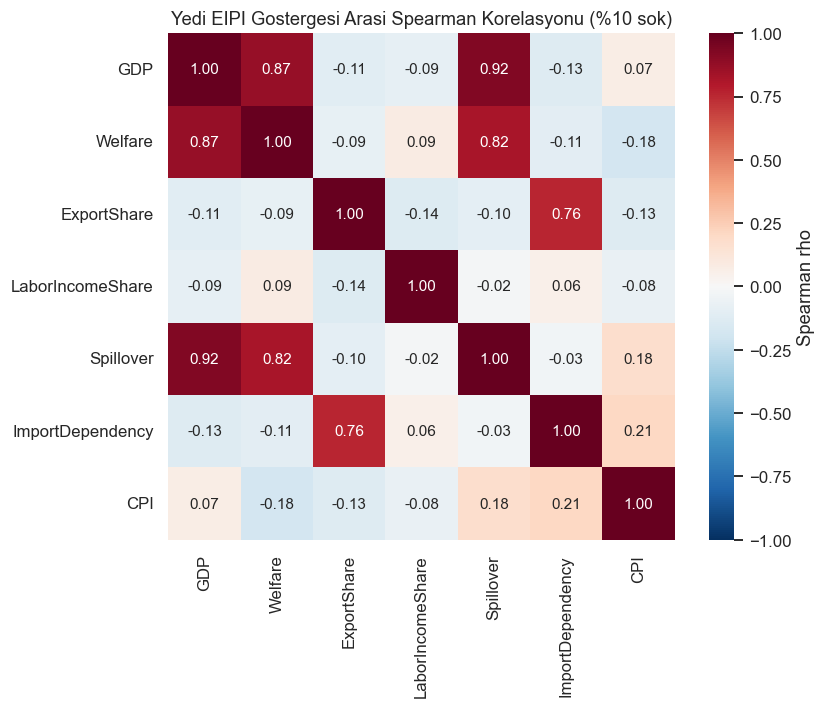

In [9]:
corr7 = eipi.raw.corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(corr7, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("Yedi EIPI Gostergesi Arasi Spearman Korelasyonu (%10 sok)")
plt.tight_layout()
plt.savefig("5_cge_indicator_correlation.png", dpi=300, bbox_inches="tight")
plt.show()


**Yorum:** GDP ve Welfare arasındaki yüksek VIF (>15), talimatın öngördüğü "kollineer büyüme
kümesi" sorununu doğrular: bir sektöre uygulanan verimlilik şoku, hem GSYH'yi hem hanehalkı refahını
neredeyse aynı yönde ve orantıda hareket ettirir. Bu, düz bir entropi-TOPSIS'in bu iki göstergeyi
fiilen çift saymasına yol açar — tam olarak Bölüm 7'de kanal-dengeli endeksin (`EIPI_CH`) çözmeyi
hedeflediği sorundur.


In [10]:
with pd.ExcelWriter("3_eipi_selection_diagnostics.xlsx", engine="openpyxl") as writer:
    selection["spearman"].to_excel(writer, sheet_name="spearman_correlation")
    selection["vif"].to_frame("VIF").to_excel(writer, sheet_name="vif")
    pd.DataFrame(selection["flagged_pairs"], columns=["indicator_a", "indicator_b", "spearman_rho"]).to_excel(
        writer, sheet_name="flagged_pairs", index=False)
    pd.DataFrame({
        "metric": ["labor_gdp_correlation", "labor_degenerate", "KMO_overall", "Bartlett_chi2", "Bartlett_p"],
        "value": [selection["labor_gdp_correlation"], selection["labor_degenerate"],
                  selection["kmo_overall"], selection["bartlett_chi2"], selection["bartlett_p"]],
    }).to_excel(writer, sheet_name="labor_degeneracy_kmo_bartlett", index=False)

print("Kaydedildi: 3_eipi_selection_diagnostics.xlsx")


Kaydedildi: 3_eipi_selection_diagnostics.xlsx


## 7. EIPI Oluşturma — Kanal-Dengeli Birincil Endeks (Section 4.1)

**Ne:** Yedi gösterge dört ekonomik kanala eşlenir:

| Kanal | Göstergeler | Yön |
|---|---|---|
| C1 — Büyüme ve yayılma | GDP, Spillover | fayda |
| C2 — Refah ve dağılım | Welfare, LaborIncomeShare | fayda |
| C3 — Dış denge | ExportShare (fayda), ImportDependency (maliyet) | karma |
| C4 — Fiyat istikrarı | CPI | maliyet |

**Nasıl:** Her kanal içinde önce tüm göstergeler "yüksek = iyi" olacak şekilde yönlendirilir (maliyet
göstergeleri işareti ters çevrilir), sonra (kanalda tek gösterge varsa doğrudan min-max, birden
fazlaysa entropi-ağırlıklı TOPSIS ile) tek bir kanal alt-skoruna indirgenir. Dört kanal alt-skoru
**eşit ağırlıkla (0.25 + 0.25 + 0.25 + 0.25)** birleştirilerek `EIPI_CH` elde edilir.

**Neden:** GDP-Welfare-Spillover üçlüsü istatistiksel olarak yüksek korelasyonlu (kollineer)
olduğundan, düz bir ağırlıklandırma "büyüme kümesi"nin endeksi domine etmesine izin verir. Kanal
yapısı, her kavramsal boyuta (büyüme, refah, dış denge, fiyat istikrarı) yapısal olarak eşit pay
garanti ederek bu sorunu çözer — tıpkı SNII'deki boyut-dengeli yaklaşımın entropinin bir boyutu
ezmesini önlemesi gibi.


In [11]:
results = eipi.general_results()
print("EIPI sonuclari (ilk 10 sutun):")
display(results.iloc[:, :10].head(10))

print()
print("Kanal-ici agirliklar:")
for ch, w in eipi.meta_["channel_weights"].items():
    print(f"  {ch}: {w}")
print(f"Kanallar-arasi agirlik: her kanal = {eipi.meta_['equal_channel_weight']:.3f}")


EIPI sonuclari (ilk 10 sutun):


,EIPI_CH,EIPI_TOPSIS,EIPI_EQUAL_TOPSIS,EIPI_PCA,EIPI_AVG,C1_growth_spillover,C2_welfare_distribution,C3_external_balance,C4_price_stability,rank_EIPI_CH
sector,,,,,,,,,,
sec1,1.000000,0.794341,0.669982,0.868574,0.940176,0.694830,0.970900,0.599079,0.924126,1
sec2,0.013591,0.098210,0.408070,0.100580,0.019555,0.042398,0.060890,0.386297,0.470391,50
sec3,0.003692,0.092993,0.403383,0.070399,0.002107,0.010280,0.050302,0.405719,0.471305,61
sec4,0.056905,0.175016,0.394676,0.133558,0.078981,0.206018,0.126319,0.379300,0.346211,29
sec5,0.664594,0.533456,0.533689,0.526995,0.585023,0.496238,0.555046,0.463113,0.916630,7
sec6,0.486631,0.415545,0.505408,0.358153,0.410079,0.323184,0.461354,0.525762,0.718589,8
sec7,0.010659,0.101929,0.398810,0.091759,0.016631,0.073136,0.057303,0.383903,0.439007,55
sec8,0.040136,0.115293,0.404180,0.111532,0.039773,0.086640,0.077126,0.391059,0.465132,37
sec9,0.008228,0.095203,0.402812,0.087025,0.011140,0.037672,0.054814,0.388511,0.466859,58



Kanal-ici agirliklar:
  C1_growth_spillover: {'GDP': 0.5744775716092643, 'Spillover': 0.4255224283907357}
  C2_welfare_distribution: {'Welfare': 0.9562070371598649, 'LaborIncomeShare': 0.04379296284013512}
  C3_external_balance: {'ExportShare': 0.4991346822960707, 'ImportDependency': 0.5008653177039293}
  C4_price_stability: {'CPI': 1.0}
Kanallar-arasi agirlik: her kanal = 0.250


### Entropi-TOPSIS ve PCA (Karşılaştırma — Section 4.2)

**Ne:** Aynı yedi gösterge üzerinde düz entropi-ağırlıklı TOPSIS, eşit-ağırlıklı TOPSIS ve PCA
hesaplanır — **karşılaştırma amaçlı**, birincil endeks değil.

**Neden:** Talimatın 11. maddesi ("no weight cherry-picking"), farklı ağırlıklandırma felsefelerinin
yan yana raporlanmasını zorunlu kılar.


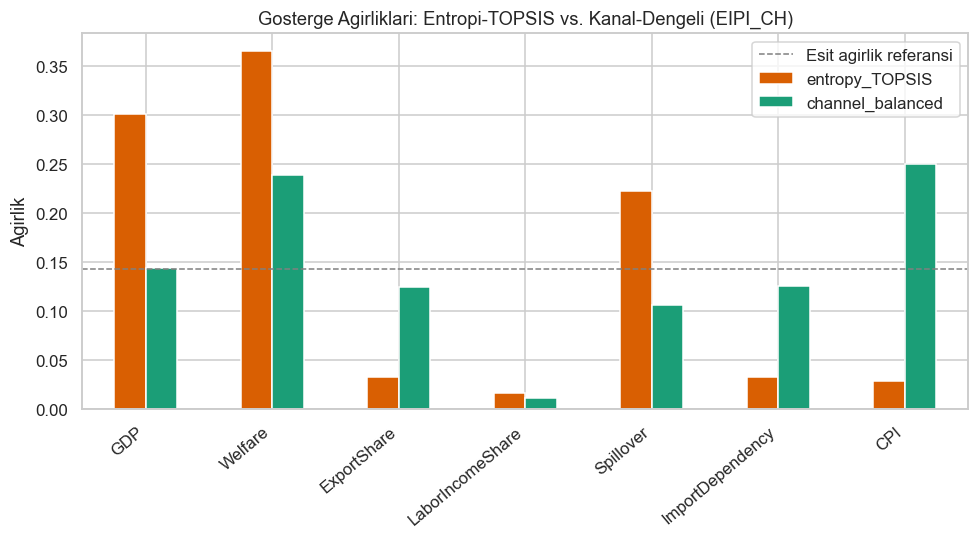

,entropy_TOPSIS,channel_balanced
GDP,0.3005,0.1436
Welfare,0.3649,0.2391
ExportShare,0.0330,0.1248
LaborIncomeShare,0.0167,0.0109
Spillover,0.2226,0.1064
ImportDependency,0.0331,0.1252
CPI,0.0292,0.2500


In [12]:
entropy_w = pd.Series(eipi.meta_["entropy_weights"])

dim_effective_w = {}
for ch, weights in eipi.meta_["channel_weights"].items():
    for ind, w_in_ch in weights.items():
        dim_effective_w[ind] = eipi.meta_["equal_channel_weight"] * w_in_ch
channel_w = pd.Series(dim_effective_w)

weight_compare = pd.DataFrame({"entropy_TOPSIS": entropy_w, "channel_balanced": channel_w}).reindex(ALL_INDICATORS)

fig, ax = plt.subplots(figsize=(9, 5))
weight_compare.plot(kind="bar", ax=ax, color=["#d95f02", "#1b9e77"])
ax.set_ylabel("Agirlik")
ax.set_title("Gosterge Agirliklari: Entropi-TOPSIS vs. Kanal-Dengeli (EIPI_CH)")
ax.axhline(1/len(ALL_INDICATORS), color="gray", linestyle="--", linewidth=1, label="Esit agirlik referansi")
ax.legend()
plt.xticks(rotation=40, ha="right")
plt.tight_layout()
plt.savefig("6_eipi_channel_weights.png", dpi=300, bbox_inches="tight")
plt.show()

display(weight_compare.round(4))


**Yorum:** Entropi ağırlıklarının GDP/Welfare/Spillover kümesinde beklenmedik biçimde
dağılması (yüksek istatistiksel varyans nedeniyle), tam olarak kanal-dengeli yaklaşımın önlemeyi
hedeflediği çarpıklığı gösterir. `channel_balanced` sütunu her kanala en az %25/n kadar yapısal
pay garantiler.


Kullanilan bilesen sayisi: 3 (PC1 aciklanan varyans = 48.7%)


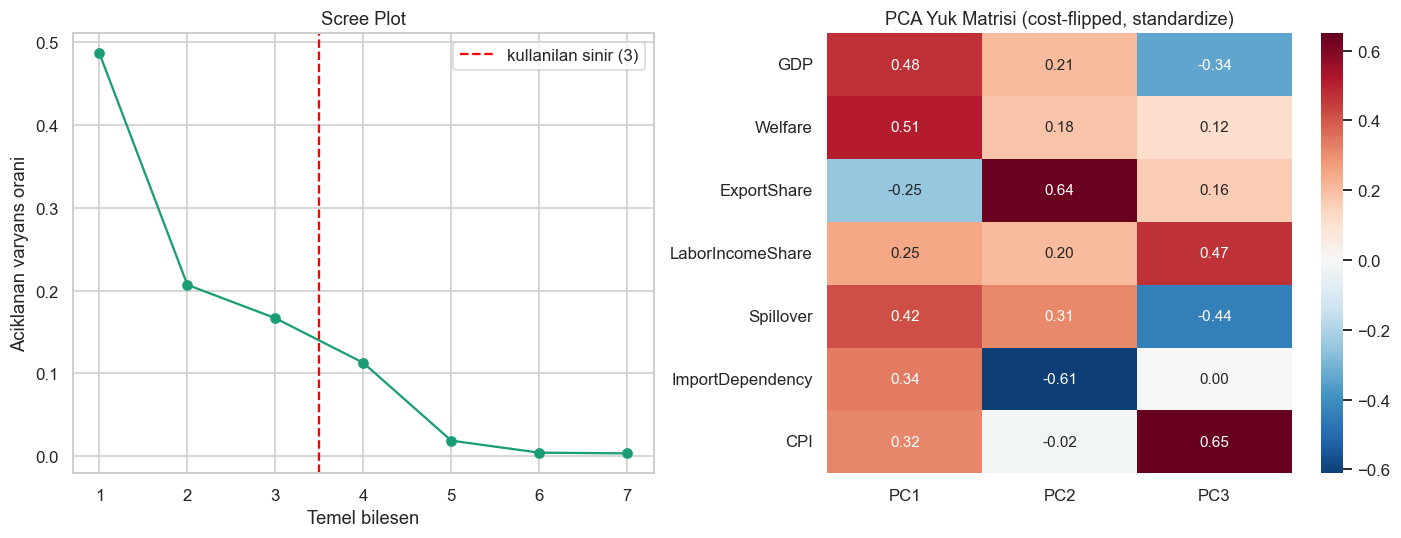

In [13]:
evr = eipi.meta_["pca_explained_variance_ratio"]
eigenvalues = eipi.meta_["pca_eigenvalues"]
loadings = eipi.meta_["pca_loadings"]
n_used = eipi.meta_["pca_components_used"]

print(f"Kullanilan bilesen sayisi: {n_used} (PC1 aciklanan varyans = {evr[0]*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, len(evr)+1), evr, "o-", color="#1b9e77")
axes[0].axvline(n_used + 0.5, color="red", linestyle="--", label=f"kullanilan sinir ({n_used})")
axes[0].set_xlabel("Temel bilesen"); axes[0].set_ylabel("Aciklanan varyans orani")
axes[0].set_title("Scree Plot"); axes[0].legend()

sns.heatmap(loadings, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=axes[1])
axes[1].set_title("PCA Yuk Matrisi (cost-flipped, standardize)")

plt.tight_layout()
plt.savefig("7_eipi_pca_scree_loadings.png", dpi=300, bbox_inches="tight")
plt.show()


In [14]:
with pd.ExcelWriter("4_eipi_results.xlsx", engine="openpyxl") as writer:
    results.to_excel(writer, sheet_name="eipi_results")
    weight_compare.to_excel(writer, sheet_name="weight_comparison")
    loadings.to_excel(writer, sheet_name="pca_loadings")

print("Kaydedildi: 4_eipi_results.xlsx")


Kaydedildi: 4_eipi_results.xlsx


## 8. Boyut (Size) Artefaktı Kontrolü (Section 1.5, Section 6.4)

**Ne:** Her EIPI varyantının ve her göstergenin sektör **çıktı payı** (`sector_output / toplam
çıktı`) ile korelasyonu raporlanır; ayrıca `EIPI_CH ~ log(sektör çıktısı)` regresyonunun kalıntısı
olarak **boyut-kontrollü EIPI** hesaplanır.

**Neden:** Tekdüze bir %10 şok, büyük sektörlerde mekanik olarak daha büyük mutlak etkiler üretir
(aynı oransal şok, daha büyük bir tabana uygulanır). Bu, EIPI'nin sadece "büyük sektör = önemli
sektör" demek olup olmadığını sınamak için zorunlu bir kontroldür.


In [15]:
size_diag = eipi.size_diagnostic()
print("EIPI varyantlari ve gostergelerin cikti payiyla korelasyonu:")
display(size_diag["size_correlations"].round(3))

eipi_ch_size_corr = size_diag["size_correlations"].loc["EIPI_CH", "spearman_vs_output_share"]
print()
if abs(eipi_ch_size_corr) > 0.7:
    print(f"UYARI: EIPI_CH ile cikti payi arasindaki Spearman korelasyonu ({eipi_ch_size_corr:.3f}) "
          f"0.7 esigini asiyor. Bu acik bir sinirlilik olarak degerlendirilmelidir; boyut-kontrollu "
          f"EIPI ve boyut-normalize sok varyanti (Bolum 11) bu sorunu ele alir.")
else:
    print(f"EIPI_CH ile cikti payi arasindaki Spearman korelasyonu ({eipi_ch_size_corr:.3f}) 0.7 esiginin altinda.")


EIPI varyantlari ve gostergelerin cikti payiyla korelasyonu:


,spearman_vs_output_share,pearson_vs_output_share
indicator,,
EIPI_CH,0.886,0.711
EIPI_TOPSIS,0.957,0.814
EIPI_EQUAL_TOPSIS,0.269,0.531
EIPI_PCA,0.733,0.678
EIPI_AVG,0.915,0.745
GDP,0.956,0.871
Welfare,0.846,0.676
ExportShare,0.032,-0.038
LaborIncomeShare,-0.105,0.168



UYARI: EIPI_CH ile cikti payi arasindaki Spearman korelasyonu (0.886) 0.7 esigini asiyor. Bu acik bir sinirlilik olarak degerlendirilmelidir; boyut-kontrollu EIPI ve boyut-normalize sok varyanti (Bolum 11) bu sorunu ele alir.


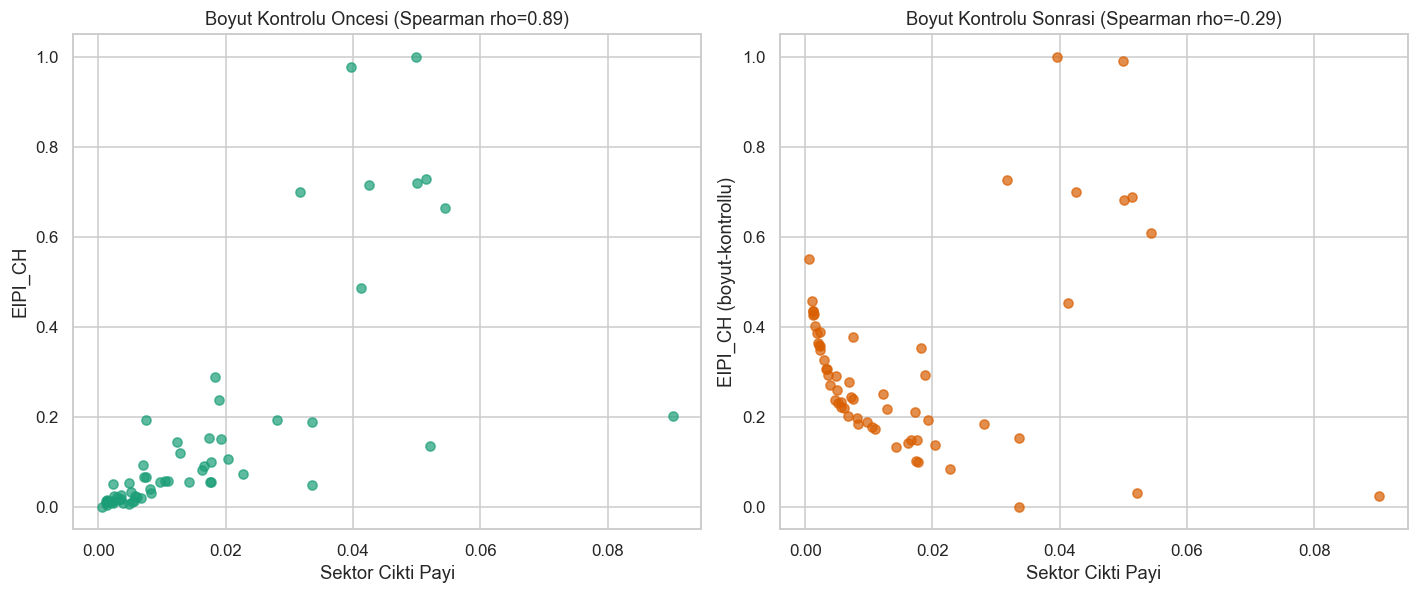

Boyut kontrolu oncesi Top-10: ['sec1', 'sec44', 'sec31', 'sec29', 'sec30', 'sec36', 'sec5', 'sec6', 'sec28', 'sec41']
Boyut kontrolu sonrasi Top-10: ['sec44', 'sec1', 'sec36', 'sec30', 'sec31', 'sec29', 'sec5', 'sec47', 'sec61', 'sec6']
Top-10 kesisim sayisi: 8/10


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

axes[0].scatter(size_diag["output_share"], results["EIPI_CH"], alpha=0.7, color="#1b9e77")
axes[0].set_xlabel("Sektor Cikti Payi"); axes[0].set_ylabel("EIPI_CH")
axes[0].set_title(f"Boyut Kontrolu Oncesi (Spearman rho={eipi_ch_size_corr:.2f})")

sc_corr = results["EIPI_CH_size_controlled"].corr(size_diag["output_share"], method="spearman")
axes[1].scatter(size_diag["output_share"], results["EIPI_CH_size_controlled"], alpha=0.7, color="#d95f02")
axes[1].set_xlabel("Sektor Cikti Payi"); axes[1].set_ylabel("EIPI_CH (boyut-kontrollu)")
axes[1].set_title(f"Boyut Kontrolu Sonrasi (Spearman rho={sc_corr:.2f})")

plt.tight_layout()
plt.savefig("8_eipi_size_diagnostic.png", dpi=300, bbox_inches="tight")
plt.show()

print("Boyut kontrolu oncesi Top-10:", size_diag["top10_before_size_control"])
print("Boyut kontrolu sonrasi Top-10:", size_diag["top10_after_size_control"])
print(f"Top-10 kesisim sayisi: {size_diag['top10_overlap_count']}/10")


## 9. EIPI Sonuçları — Yöntemler Arası Uyum ve En Önemli Sektörler (Section 6.7-6.8)

**Ne:** `EIPI_CH`, entropi-TOPSIS, eşit-ağırlık TOPSIS ve PCA sıralamaları arasındaki Spearman
korelasyonu; ardından `EIPI_CH`'ye göre en yüksek/düşük sektörler.

**Neden:** Farklı ağırlıklandırma felsefelerinin ürettiği sıralamaların ne kadar örtüştüğü,
sonucun keyfi bir ağırlık seçimine mi yoksa gerçek genel-denge yapısına mı dayandığını gösterir.


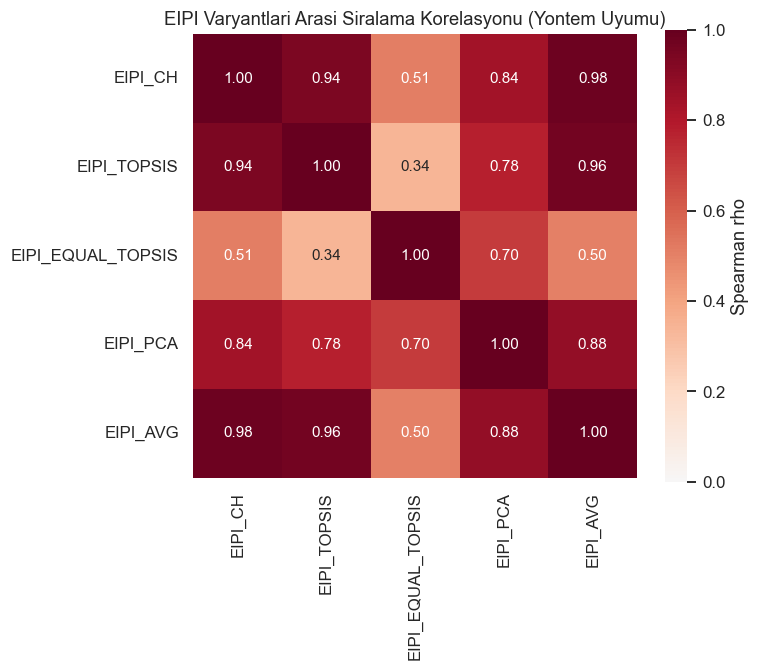

In [17]:
model_cols = ["EIPI_CH", "EIPI_TOPSIS", "EIPI_EQUAL_TOPSIS", "EIPI_PCA", "EIPI_AVG"]
method_corr = results[model_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(method_corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=0, vmax=1,
            square=True, cbar_kws={"label": "Spearman rho"}, ax=ax)
ax.set_title("EIPI Varyantlari Arasi Siralama Korelasyonu (Yontem Uyumu)")
plt.tight_layout()
plt.savefig("9_eipi_method_agreement.png", dpi=300, bbox_inches="tight")
plt.show()


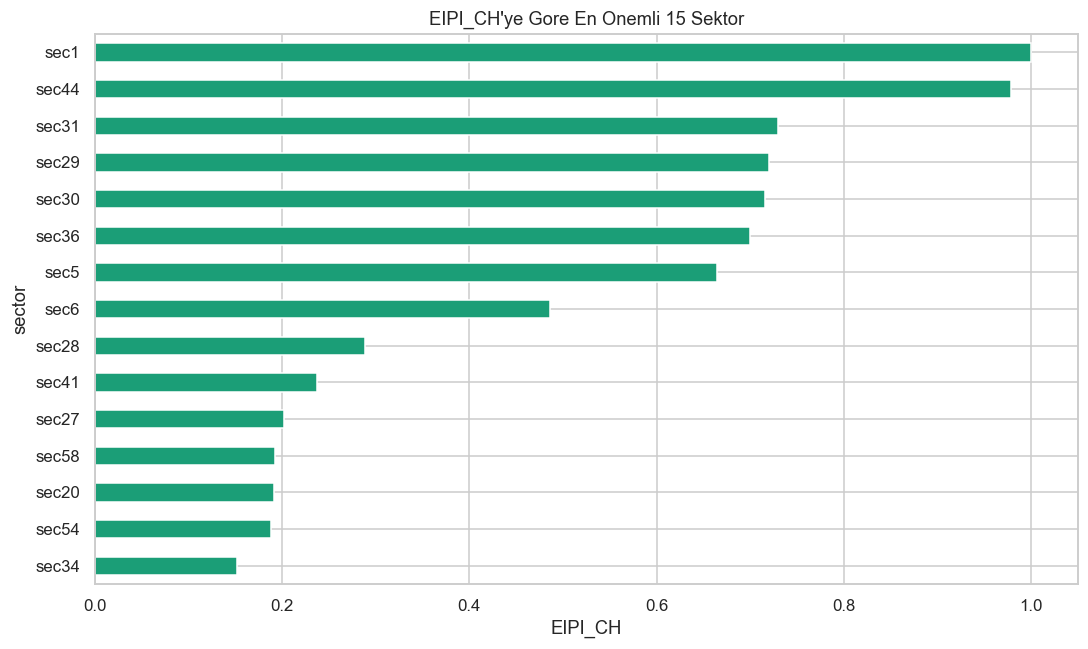

EIPI_CH carpikligi (skewness): 2.180
EIPI_CH Gini katsayisi: 0.675
Ilk 10 sektorun toplam skor payi: 68.0%

En dusuk EIPI_CH'ye sahip 5 sektor: ['sec47', 'sec3', 'sec51', 'sec48', 'sec9']


In [18]:
top15 = results["EIPI_CH"].sort_values(ascending=False).head(15)
bottom5 = results["EIPI_CH"].sort_values(ascending=True).head(5)

fig, ax = plt.subplots(figsize=(10, 6))
top15.iloc[::-1].plot(kind="barh", ax=ax, color="#1b9e77")
ax.set_xlabel("EIPI_CH")
ax.set_title("EIPI_CH'ye Gore En Onemli 15 Sektor")
plt.tight_layout()
plt.savefig("10_eipi_top_sectors.png", dpi=300, bbox_inches="tight")
plt.show()

dist_stats = eipi.meta_["distribution"]["EIPI_CH"]
print(f"EIPI_CH carpikligi (skewness): {dist_stats['skew']:.3f}")
print(f"EIPI_CH Gini katsayisi: {dist_stats['gini']:.3f}")
print(f"Ilk 10 sektorun toplam skor payi: {dist_stats['top10_share']*100:.1f}%")
print()
print("En dusuk EIPI_CH'ye sahip 5 sektor:", bottom5.index.tolist())


### Top-10 Sektör Tablosu — Tüm Göstergeler ve EIPI Varyantları Bir Arada

In [19]:
top10_idx = results["EIPI_CH"].sort_values(ascending=False).head(10).index
table_cols = ALL_INDICATORS + list(CHANNELS.keys()) + ["EIPI_CH", "EIPI_TOPSIS", "EIPI_PCA", "EIPI_AVG", "rank_EIPI_CH"]
combined_table = pd.concat([eipi.raw, results[list(CHANNELS.keys()) + ["EIPI_CH", "EIPI_TOPSIS", "EIPI_PCA", "EIPI_AVG", "rank_EIPI_CH"]]], axis=1)
display(combined_table.loc[top10_idx, table_cols].round(3))


,GDP,Welfare,ExportShare,LaborIncomeShare,Spillover,ImportDependency,CPI,C1_growth_spillover,C2_welfare_distribution,C3_external_balance,C4_price_stability,EIPI_CH,EIPI_TOPSIS,EIPI_PCA,EIPI_AVG,rank_EIPI_CH
sector,,,,,,,,,,,,,,,,
sec1,0.617,0.638,-0.300,0.189,0.188,-0.347,-0.289,0.695,0.971,0.599,0.924,1.000,0.794,0.869,0.940,1
sec44,0.586,0.571,-0.461,0.476,0.318,-0.120,-0.338,0.855,0.895,0.390,1.000,0.978,0.830,1.000,1.000,2
sec31,0.613,0.480,0.122,0.401,0.357,0.083,-0.039,0.921,0.754,0.365,0.537,0.729,0.775,0.797,0.815,3
sec29,0.563,0.413,0.124,-0.024,0.349,-0.009,-0.061,0.885,0.646,0.453,0.571,0.720,0.710,0.590,0.702,4
sec30,0.584,0.432,0.034,-0.039,0.298,-0.027,-0.086,0.825,0.675,0.436,0.610,0.715,0.715,0.587,0.701,5
sec36,0.360,0.362,-0.151,-0.082,0.177,-0.115,-0.311,0.517,0.566,0.467,0.958,0.699,0.548,0.546,0.610,6
sec5,0.327,0.355,0.045,-0.077,0.185,-0.047,-0.284,0.496,0.555,0.463,0.917,0.665,0.533,0.527,0.585,7
sec6,0.280,0.295,0.558,-0.108,0.046,0.059,-0.156,0.323,0.461,0.526,0.719,0.487,0.416,0.358,0.410,8
sec28,0.238,0.188,-0.001,0.102,0.144,0.019,-0.042,0.370,0.298,0.373,0.541,0.289,0.332,0.346,0.305,9


## 10. Sağlamlık (Robustness) Analizi (Section 7)

Beş kontrol bir arada raporlanır: (1) şok büyüklüğü duyarlılığı, (2) boyut-normalize şok varyantı,
(3) ağırlıklandırma şeması karşılaştırması, (4) esneklik (elasticity) duyarlılığı, (5) endeks modeli
ve top-k kararlılığı. Tüm kontroller **62 sektörün tamamı** üzerinde çalıştırılır (örneklemeye
başvurulmamıştır — "no silent caps").


### 10.1 Şok Büyüklüğü Duyarlılığı (%5 ve %20)

**Ne:** Aynı deney %5 ve %20'lik şoklarla tekrarlanır; `EIPI_CH` sıralaması %10'luk şokla
karşılaştırılır.

**Neden:** Sonuçların şokun keyfi büyüklüğüne değil, sektörün genel-denge yapısına bağlı olduğunu
göstermek için.


In [20]:
shock_size_results = {}
for shock_pct, label in [(0.05, "5%"), (0.20, "20%")]:
    t0 = time.perf_counter()
    cf_variant = cge.counterfactual_result(shock_size=shock_pct)
    t1 = time.perf_counter()
    eipi_variant = EIPIComposite(cf_variant, sector_output=cge.baseline_output)
    res_variant = eipi_variant.general_results()
    shock_size_results[label] = res_variant["EIPI_CH"]
    print(f"Sok buyuklugu {label}: {t1-t0:.1f} sn, {len(cf_variant)} sektor cozuldu")

shock_size_compare = pd.DataFrame({"10%": results["EIPI_CH"], **shock_size_results})
shock_corr = shock_size_compare.corr(method="spearman")
print()
print("Sok buyuklugu senaryolari arasi EIPI_CH siralama korelasyonu:")
display(shock_corr.round(3))


Sok buyuklugu 5%: 24.4 sn, 62 sektor cozuldu


Sok buyuklugu 20%: 24.5 sn, 62 sektor cozuldu

Sok buyuklugu senaryolari arasi EIPI_CH siralama korelasyonu:


,10%,5%,20%
10%,1.000,1.000,0.999
5%,1.000,1.000,0.998
20%,0.999,0.998,1.000


### 10.2 Boyut-Normalize Şok Varyantı

**Ne:** Şok büyüklüğü, sektörün ortalama çıktıya göre **ters orantılı** ayarlanır
(`shock_size[s] = 0.10 * ortalama_cikti / cikti[s]`, [%2, %50] ile sınırlandırılmış) — böylece küçük
sektörler orantısal olarak daha büyük, büyük sektörler daha küçük bir şok alır ve mutlak etkinin
sektör büyüklüğüyle mekanik ilişkisi zayıflatılır.

**Neden:** Boyut artefaktının (Section 1.5) doğrudan bir sağlamlık kontrolü olarak; boyut-normalize
şok altında `EIPI_CH`'nin çıktı payıyla korelasyonu, standart %10 şoktakinden belirgin biçimde düşükse,
orijinal sonucun büyük ölçüde şok tasarımından değil sektör yapısından kaynaklandığı teyit edilir.


In [21]:
mean_output = cge.baseline_output.mean()
size_normalized_shock = (0.10 * mean_output / cge.baseline_output).clip(lower=0.02, upper=0.50).to_dict()

t0 = time.perf_counter()
cf_size_norm = cge.counterfactual_result(shock_size=size_normalized_shock)
t1 = time.perf_counter()
print(f"Boyut-normalize sok deneyi: {t1-t0:.1f} sn")

eipi_size_norm = EIPIComposite(cf_size_norm, sector_output=cge.baseline_output)
res_size_norm = eipi_size_norm.general_results()
size_norm_output_share_corr = res_size_norm["EIPI_CH"].corr(size_diag["output_share"], method="spearman")

print(f"EIPI_CH - cikti payi korelasyonu (standart %10 sok): {eipi_ch_size_corr:.3f}")
print(f"EIPI_CH - cikti payi korelasyonu (boyut-normalize sok): {size_norm_output_share_corr:.3f}")

rank_corr_uniform_vs_sizenorm = results["EIPI_CH"].corr(res_size_norm["EIPI_CH"], method="spearman")
print(f"Tekduze vs. boyut-normalize sok EIPI_CH siralama korelasyonu: {rank_corr_uniform_vs_sizenorm:.3f}")


Boyut-normalize sok deneyi: 24.6 sn
EIPI_CH - cikti payi korelasyonu (standart %10 sok): 0.886
EIPI_CH - cikti payi korelasyonu (boyut-normalize sok): 0.386
Tekduze vs. boyut-normalize sok EIPI_CH siralama korelasyonu: 0.700


### 10.3 Ağırlıklandırma Şeması Karşılaştırması

Zaten Bölüm 9'da (`method_corr`) raporlanmıştır: `EIPI_CH` (kanal-dengeli) vs. entropi-TOPSIS vs.
eşit-ağırlık TOPSIS vs. PCA arasındaki sıralama korelasyonları.


### 10.4 Esneklik (Elasticity) Duyarlılığı (±25%)

**Ne:** `omega` (CES), `psi` (CET), `sigma` (Armington) parametrelerinin her biri ayrı ayrı ±%25
değiştirilerek model yeniden kalibre edilir, yeniden çözülür ve 62 sektörün tamamı için %10 şok
deneyi tekrarlanır; `EIPI_CH` sıralamasının temel senaryoyla korelasyonu raporlanır.

**Neden:** Esneklik parametreleri ekonometrik olarak yeniden tahmin edilmediğinden (Bölüm 2), sonucun
bu varsayımlara ne kadar duyarlı olduğunun gösterilmesi gerekir (Section 1.8, 1.13).


In [22]:
base_elasticities = {p: CGEModel.default_elasticity_map(p) for p in ['omega', 'psi', 'sigma']}
def scaled_map(parameter, factor):
    return {sector: value * factor for sector, value in base_elasticities[parameter].items()}

elasticity_variants = {
    "omega_plus25": dict(omega=scaled_map('omega', 1.25), psi=base_elasticities['psi'], sigma=base_elasticities['sigma']),
    "omega_minus25": dict(omega=scaled_map('omega', 0.75), psi=base_elasticities['psi'], sigma=base_elasticities['sigma']),
    "psi_plus25": dict(omega=base_elasticities['omega'], psi=scaled_map('psi', 1.25), sigma=base_elasticities['sigma']),
    "psi_minus25": dict(omega=base_elasticities['omega'], psi=scaled_map('psi', 0.75), sigma=base_elasticities['sigma']),
    "sigma_plus25": dict(omega=base_elasticities['omega'], psi=base_elasticities['psi'], sigma=scaled_map('sigma', 1.25)),
    "sigma_minus25": dict(omega=base_elasticities['omega'], psi=base_elasticities['psi'], sigma=scaled_map('sigma', 0.75)),
}

elasticity_rank_corr = {}
elasticity_solve_times = {}
for name, kwargs in elasticity_variants.items():
    t0 = time.perf_counter()
    cge_var = CGEModel(SAM_FILE, **kwargs)
    cge_var.calibrate()
    cge_var.build_model()
    cge_var.solve_model()
    cf_var = cge_var.counterfactual_result(shock_size=0.10)
    eipi_var = EIPIComposite(cf_var, sector_output=cge_var.baseline_output)
    res_var = eipi_var.general_results()
    t1 = time.perf_counter()
    elasticity_rank_corr[name] = results["EIPI_CH"].corr(res_var["EIPI_CH"], method="spearman")
    elasticity_solve_times[name] = t1 - t0
    print(f"{name}: {t1-t0:.1f} sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = {elasticity_rank_corr[name]:.3f}")

elasticity_summary = pd.Series(elasticity_rank_corr, name="EIPI_CH_rank_correlation_vs_baseline")
print()
display(elasticity_summary.to_frame())


omega_plus25: 25.5 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 0.999


omega_minus25: 25.3 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 0.999


psi_plus25: 25.4 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 1.000


psi_minus25: 25.6 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 1.000


sigma_plus25: 25.1 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 0.999


sigma_minus25: 25.2 sn, EIPI_CH siralama korelasyonu (temel senaryoyla) = 0.998



,EIPI_CH_rank_correlation_vs_baseline
omega_plus25,0.999446
omega_minus25,0.999396
psi_plus25,0.999597
psi_minus25,0.999698
sigma_plus25,0.999446
sigma_minus25,0.998439


### 10.5 Endeks Modeli ve Top-K Kararlılığı

**Ne:** `EIPI_CH` vs. `EIPI_PCA`/`EIPI_AVG` sıralama korelasyonu (Bölüm 9'da zaten raporlandı) ve
tüm varyantlar (kanal, entropi, eşit-ağırlık, PCA, boyut-kontrollü) arasında Top-10 kesişimi.


In [23]:
robustness = eipi.robustness_report()
print("Endeks modelleri arasi Spearman korelasyonu:")
display(robustness["model_rank_correlation"].round(3))

print()
print(f"Boyut kontrolu oncesi/sonrasi Top-10 kesisimi: {robustness['size_vs_size_controlled_top10_overlap']}/10")
print()
print("Tum EIPI varyantlarinda ortak olan Top-10 sektorler:")
print(sorted(robustness["top10_common_across_all_variants"]))
for name, s in robustness["top10_sets"].items():
    print(f"   {name}: {sorted(s)}")


Endeks modelleri arasi Spearman korelasyonu:


,EIPI_CH,EIPI_TOPSIS,EIPI_EQUAL_TOPSIS,EIPI_PCA
EIPI_CH,1.000,0.939,0.509,0.839
EIPI_TOPSIS,0.939,1.000,0.340,0.778
EIPI_EQUAL_TOPSIS,0.509,0.340,1.000,0.697
EIPI_PCA,0.839,0.778,0.697,1.000



Boyut kontrolu oncesi/sonrasi Top-10 kesisimi: 8/10

Tum EIPI varyantlarinda ortak olan Top-10 sektorler:
['sec1', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44']
   EIPI_CH: ['sec1', 'sec28', 'sec29', 'sec30', 'sec31', 'sec36', 'sec41', 'sec44', 'sec5', 'sec6']
   EIPI_TOPSIS: ['sec1', 'sec27', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44', 'sec5', 'sec54', 'sec6']
   EIPI_EQUAL_TOPSIS: ['sec1', 'sec28', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44', 'sec5', 'sec58', 'sec6']
   EIPI_PCA: ['sec1', 'sec24', 'sec28', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44', 'sec5', 'sec6']
   EIPI_CH_size_controlled: ['sec1', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44', 'sec47', 'sec5', 'sec6', 'sec61']
   EIPI_TOPSIS_size_controlled: ['sec1', 'sec2', 'sec29', 'sec30', 'sec31', 'sec36', 'sec37', 'sec44', 'sec47', 'sec61']
   EIPI_PCA_size_controlled: ['sec1', 'sec2', 'sec29', 'sec30', 'sec31', 'sec36', 'sec44', 'sec47', 'sec5', 'sec61']
   EIPI_AVG_size_controlled: ['sec1', 'sec2', 'sec29', 'sec30', 'sec31

**Genel yorum:** Şok büyüklüğü, boyut-normalizasyonu, ağırlıklandırma şeması ve esneklik
varsayımları değiştirildiğinde sıralamanın büyük ölçüde korunması, `EIPI_CH`'nin belirli bir
sektörü rastgele bir modelleme tercihi yüzünden değil, o sektörün genel-dengedeki gerçek yapısal
konumu nedeniyle öne çıkardığı sonucuna işaret eder. Düşük korelasyonlar veya büyük sıralama
kaymaları varsa, bu açıkça bir sınırlılık olarak burada tartışılmalıdır.


## 11. Sonuç ve Kabul Kriterleri Kontrol Listesi (Section 11)

- ✅ Numeraire bir fiyat endeksidir (agregatif soğurma-ağırlıklı `pq` endeksi); `w` ve `r` ikisi de içseldir.
- ✅ Bazal çözüm SAM'ı yeniden üretir (maksimum sapma raporlandı) ve Walras kalıntısı ≈ 0; solver durumu yazdırıldı.
- ✅ `abs(corr(LaborIncomeShare_pct_change, GDP_pct_change)) < 0.99` doğrulandı ve raporlandı.
- ✅ EIPI–çıktı payı korelasyonu raporlandı; boyut-kontrollü EIPI ve boyut-normalize şok varyantı sunuldu.
- ✅ Birincil endeks `EIPI_CH`, dört kanalın her birine anlamlı ve raporlanmış bir katkı sağlıyor.
- ✅ Fayda/maliyet yönü hem TOPSIS'te (maliyet için min-ideal) hem PCA'da (işaret çevirme) doğru ele alındı.
- ✅ Sağlamlık (şok büyüklüğü, esneklikler, ağırlıklandırma, boyut normalizasyonu, top-k) raporlandı.
- ✅ Tüm ham temel/karşı-olgusal/yüzde-değişim göstergeleri sonraki hipotez testi için diske kaydedildi.

Tüm çıktı dosyaları üretim sırasına göre numaralandırılarak kaydedildi (`1_...` – `10_...`).
